In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(44)
n = 100

df = pd.DataFrame({
    'CustomerID': [f'C{i:03d}' for i in range(1, n+1)],
    'Age': np.random.randint(22, 65, n),
    'Region': np.random.choice(['West','East','North','South'], n),
    'Category': np.random.choice(['Technology','Furniture','Office Supplies'], n,p=[0.5, 0.3, 0.2]),
    'OrderValue': np.concatenate([
        np.random.normal(800, 200, 80),
        np.random.normal(2500, 300, 20)
    ]),
    'DaysToShip': np.random.randint(1, 10, n),
    'Discount': np.random.uniform(0, 0.4, n).round(2)
})

df['OrderValue'] = df['OrderValue'].round(2)
print(df.shape)
print(df.head())

(100, 7)
  CustomerID  Age Region    Category  OrderValue  DaysToShip  Discount
0       C001   42  North  Technology      619.22           9      0.36
1       C002   57   West  Technology     1359.09           9      0.39
2       C003   25  South   Furniture     1103.36           2      0.16
3       C004   54  North  Technology      685.72           9      0.37
4       C005   42   East   Furniture      911.85           7      0.03


In [ ]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nLast 5 rows:")
display(df.tail())
print("\nRandom sample:")
display(df.sample(5))

Shape: (100, 7)

Data Types:
CustomerID     object
Age             int64
Region         object
Category       object
OrderValue    float64
DaysToShip      int64
Discount      float64
dtype: object

First 5 rows:


,CustomerID,Age,Region,Category,OrderValue,DaysToShip,Discount
0,C001,42,North,Technology,619.22,9,0.36
1,C002,57,West,Technology,1359.09,9,0.39
2,C003,25,South,Furniture,1103.36,2,0.16
3,C004,54,North,Technology,685.72,9,0.37
4,C005,42,East,Furniture,911.85,7,0.03



Last 5 rows:


,CustomerID,Age,Region,Category,OrderValue,DaysToShip,Discount
95,C096,52,West,Furniture,2285.30,5,0.22
96,C097,36,North,Office Supplies,2479.08,5,0.18
97,C098,57,South,Furniture,2372.17,2,0.09
98,C099,41,East,Office Supplies,2560.73,8,0.08
99,C100,33,North,Technology,2771.15,5,0.18



Random sample:


,CustomerID,Age,Region,Category,OrderValue,DaysToShip,Discount
41,C042,24,East,Technology,574.94,4,0.12
83,C084,49,East,Technology,2260.58,7,0.37
87,C088,58,North,Technology,2842.60,2,0.18
60,C061,54,South,Technology,627.21,7,0.25
11,C012,29,North,Furniture,611.23,7,0.16


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print(f"\nDuplicates: {df.duplicated().sum()}")

print("\nBasic statistics:")
display(df.describe())

print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Missing values:
CustomerID    0
Age           0
Region        0
Category      0
OrderValue    0
DaysToShip    0
Discount      0
dtype: int64

Duplicates: 0

Basic statistics:


,Age,OrderValue,DaysToShip,Discount
count,100.000000,100.000000,100.000000,100.000000
mean,44.050000,1115.205700,4.930000,0.210600
std,12.856924,690.632682,2.749674,0.112293
min,22.000000,333.190000,1.000000,0.000000
25%,32.750000,696.292500,2.750000,0.120000
50%,43.500000,853.005000,5.000000,0.210000
75%,56.250000,1090.145000,8.000000,0.300000
max,64.000000,3011.840000,9.000000,0.400000



Unique values per column:
CustomerID: 100 unique values
Age: 42 unique values
Region: 4 unique values
Category: 3 unique values
OrderValue: 100 unique values
DaysToShip: 9 unique values
Discount: 40 unique values


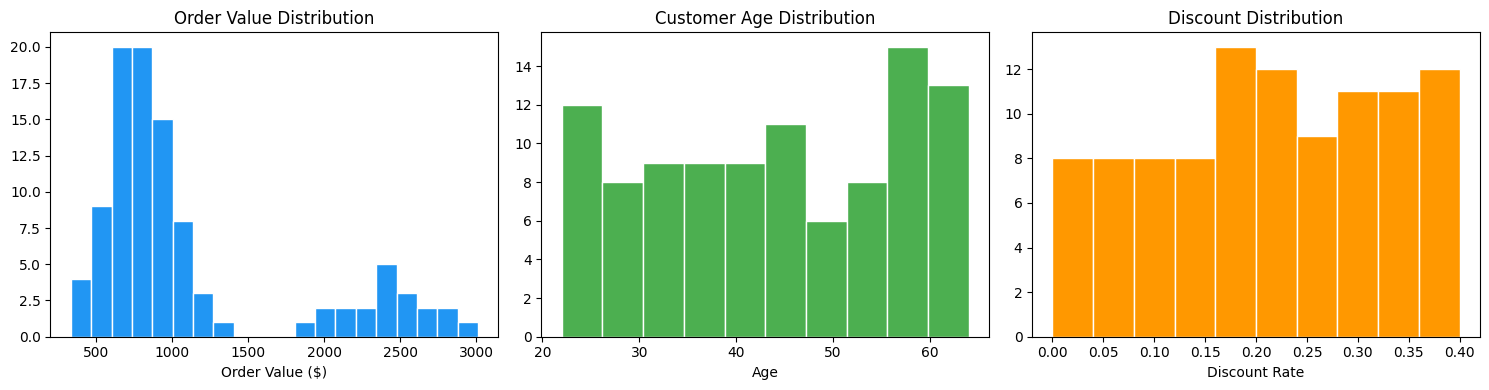

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['OrderValue'], bins=20, color='#2196F3', edgecolor='white')
axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('Order Value ($)')

axes[1].hist(df['Age'], bins=10, color='#4CAF50', edgecolor='white')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')

axes[2].hist(df['Discount'], bins=10, color='#FF9800', edgecolor='white')
axes[2].set_title('Discount Distribution')
axes[2].set_xlabel('Discount Rate')

plt.tight_layout()
plt.show()

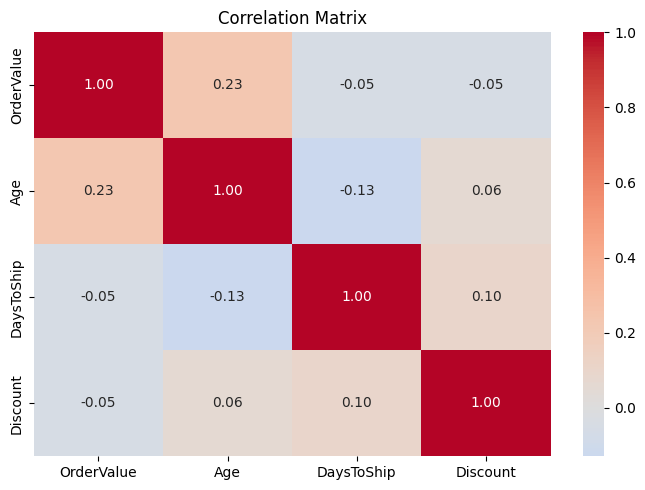

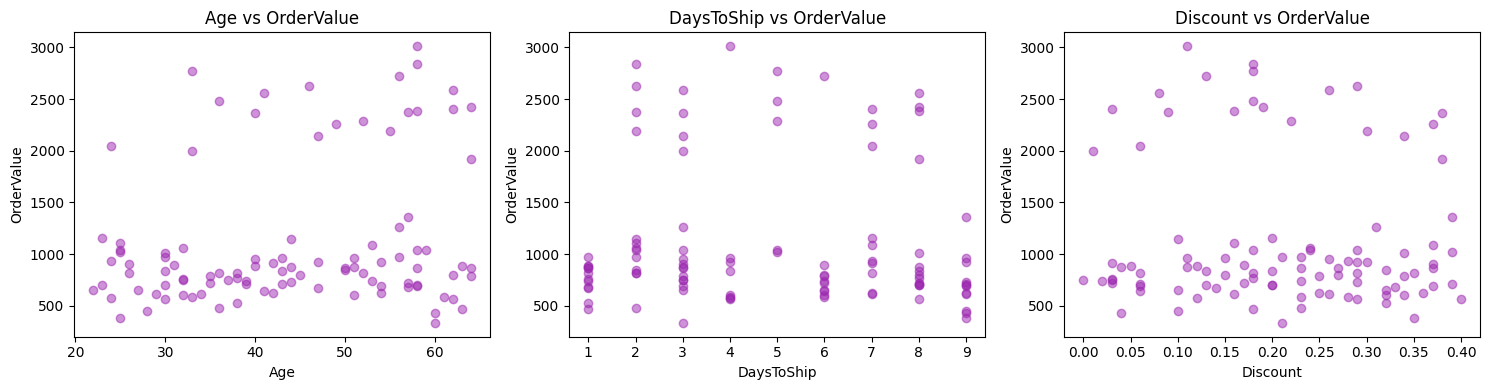

In [ ]:
numeric_cols = ['OrderValue', 'Age', 'DaysToShip', 'Discount']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'DaysToShip', 'Discount']):
    ax.scatter(df[col], df['OrderValue'], alpha=0.5, color='#9C27B0')
    ax.set_xlabel(col)
    ax.set_ylabel('OrderValue')
    ax.set_title(f'{col} vs OrderValue')

plt.tight_layout()
plt.show()

/tmp/ipykernel_773/3720039464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Region', y='OrderValue',
/tmp/ipykernel_773/3720039464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='OrderValue',


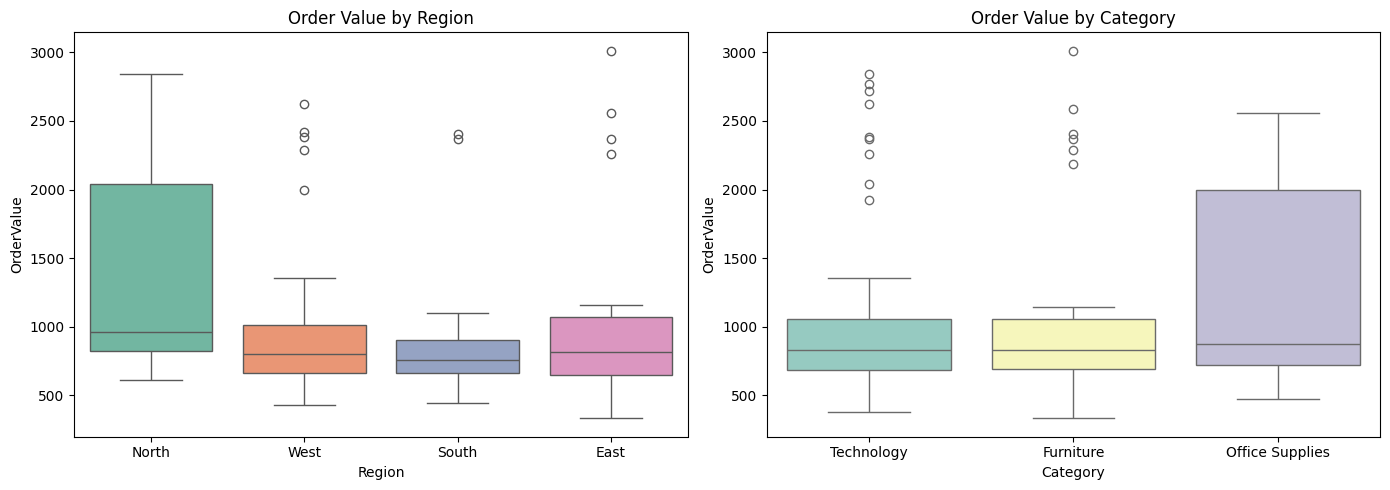


Regional summary:


,mean,median,count
Region,,,
East,1083.806364,814.88,22
North,1351.677586,963.35,29
South,897.174783,760.97,23
West,1070.890769,802.45,26



Category summary:


,mean,median,count
Category,,,
Furniture,1077.531765,830.065,34
Office Supplies,1233.558824,876.550,17
Technology,1100.285510,832.110,49


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Region', y='OrderValue',
            palette='Set2', ax=axes[0])
axes[0].set_title('Order Value by Region')

sns.boxplot(data=df, x='Category', y='OrderValue',
            palette='Set3', ax=axes[1])
axes[1].set_title('Order Value by Category')

plt.tight_layout()
plt.show()

print("\nRegional summary:")
display(df.groupby('Region')['OrderValue'].agg(['mean','median','count']))

print("\nCategory summary:")
display(df.groupby('Category')['OrderValue'].agg(['mean','median','count']))

### Exporting Data to CSV

To export your DataFrame to a CSV file, you can use the `df.to_csv()` method. This will save the DataFrame's contents to a file that you can then download or use in other applications.


In [ ]:
# Define the filename for your CSV file
csv_filename = 'customer_data.csv'

# Ensure df is defined. If this cell is run in isolation and df is not
# defined from previous cells, a NameError will occur.
# For demonstration purposes, a dummy DataFrame is created here if 'df' is not found.
# In a real scenario, ensure your 'df' DataFrame is properly
# defined and processed by executing all preceding cells that create or modify it.
if 'df' not in locals() and 'df' not in globals():
    import pandas as pd
    print("Warning: 'df' DataFrame was not found in the current environment. Creating a dummy DataFrame for export.")
    df = pd.DataFrame({'col1': [1, 2], 'col2': ['A', 'B']})


# Export the DataFrame to CSV
df.to_csv(csv_filename, index=False) # Set index=False to avoid writing the DataFrame index as a column

print(f"DataFrame successfully exported to '{csv_filename}'")

DataFrame successfully exported to 'customer_data.csv'
